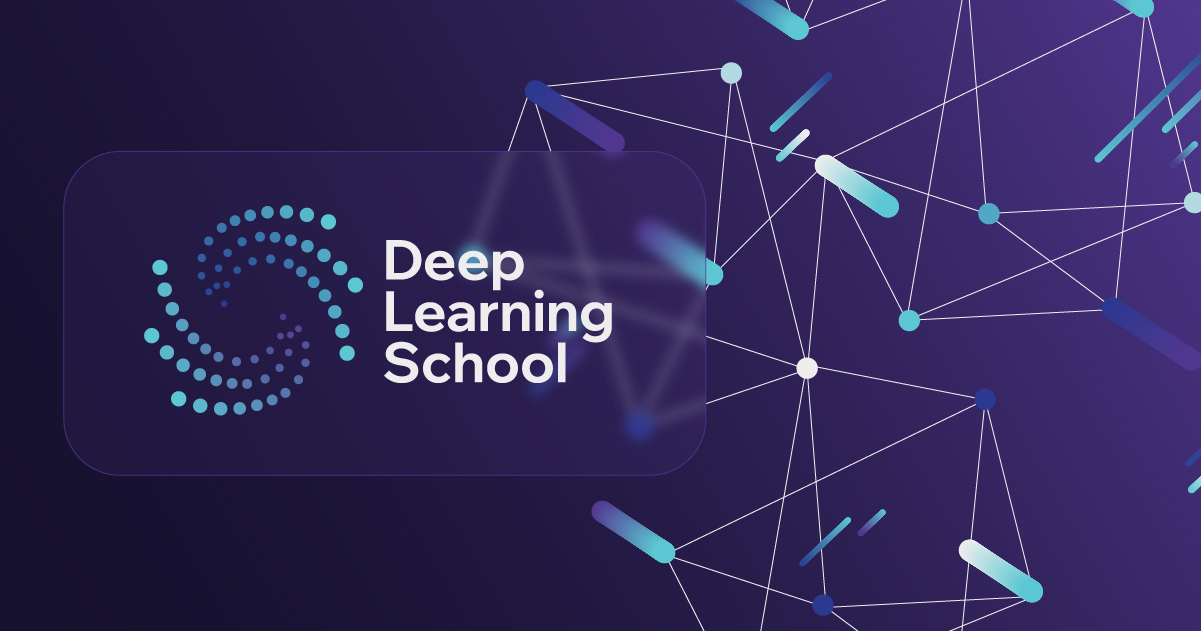

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Семинар. Convolution and pooling operations.</b></h1>


### Convolution (свёртка)

На этом семинаре мы посмотрим, как свёртки влияют на изображение и попрактикуемся в вычислении свёрток и пулингов от различных изображений.

Для начала напомним, что такое свёртка:

<img src="https://neurohive.io/wp-content/uploads/2018/07/convolutional-neural-network.gif" width=450 height=400>

*https://neurohive.io/wp-content/uploads/2018/07/convolutional-neural-network.gif*

То есть мы берём фильтр размера FxF, умножаем его на область изображения размером FxF поэлементно, складываем получившиеся поэлемнетные произведения и записываем это число в результирующий тензор.

За исключением архитектур типа MobileNet, третья размерность фильтра всегда свопадает с третьей размерностью входного тензора. Если картинка размера HxWx3, то фильтр будет иметь размер FxFx3, и поэлементное произведение будет производиться по всему объёму.

Напомним два важных параметра операции свертки:

stride -- это размер шага окна свёртка по осям x и y (обычно совпадают, но вполне могут быть и разными).

$padding$ -- это окружение картинки по краям нулями (или чем-то другим) для того, чтобы придать изображению после свёртки нужный размер (пэддинг делается до свёртки).

---

Посмотрим на то, как применение свёртки с определёнными фильтрами влияет на изображение. На этот счёт есть хорошая статья на Хабрахабре:  

https://habr.com/post/142818/

Возьмём код из статьи и посмотрим, как будет меняться картинка в зависимости от фильтра:

In [ ]:
!wget https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png -O lenna.png

--2026-04-25 14:02:34--  https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png
Resolving upload.wikimedia.org (upload.wikimedia.org)... 208.80.153.240, 2620:0:860:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|208.80.153.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 473831 (463K) [image/png]
Saving to: ‘lenna.png’

lenna.png           100%[===================>] 462.73K  --.-KB/s    in 0.1s    

2026-04-25 14:02:35 (3.65 MB/s) - ‘lenna.png’ saved [473831/473831]



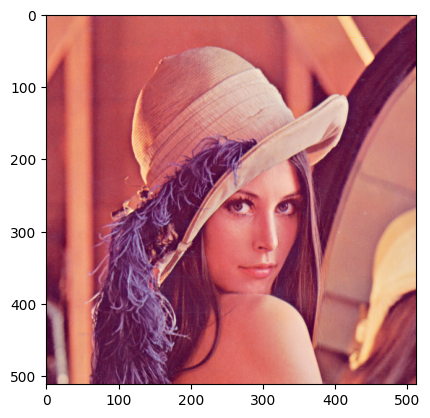

In [ ]:
from PIL import Image
from math import ceil, sqrt
from math import floor

import matplotlib.pyplot as plt

#https://habrahabr.ru/post/142818/
# Функция приводит значение яркости пикселя к допустимому диапазону [0, 255]
def checkByte(a):
    if a > 255:
        a = 255
    if a < 0:
        a = 0
    return a

# Функция свёртки двух матриц (попарное умножение и суммирование)
# a, b – двумерные списки одинакового размера
def conv(a, b):
    sum = 0
    for i in range(len(a)):
        for j in range(len(a[0])):
            sum += a[i][j] * b[i][j]
    return sum



def median(a):
    c = []
    for i in range(len(a)):
        for j in range(len(a[0])):
            c.append(a[i][j])
    c.sort()
    return c[ceil(len(c)/2)]


def max(a):
    c = []
    for i in range(len(a)):
        for j in range(len(a[0])):
            c.append(a[i][j])
    c.sort()
    return c[len(c)-1]


def min(a):
    c = []
    for i in range(len(a)):
        for j in range(len(a[0])):
            c.append(a[i][j])
    c.sort()
    return c[0]

im = Image.open('./lenna.png')
pixels = im.load()

plt.imshow(im);

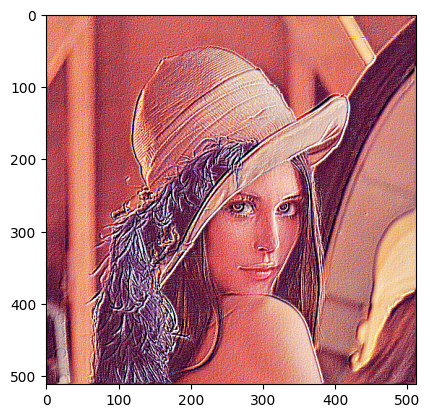

In [ ]:
imFinal = im.copy()
pixels2 = imFinal.load() #Метод .load() возвращает объект доступа к пикселям. Через него можно читать и изменять отдельные пиксели изображения по координатам (x, y).
filter = [
    [-1, -1, 0, 0, 0],
    [0, -1, -1, -1, 0],
    [0, -1, 9, -1, 0],
    [0, -1, -1, -1, 0],
    [0, 0, 0, 0, 0]
]
'''
filter = [
    [-1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1],
    [-1, -1, 4, -1, -1],
    [-1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1]
]
'''
'''
filter = [
    [0, 0, 0, 1, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 1],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 1, 0, 0, 0]
]
'''

'''
filter = [
    [-1, -1, -1],
    [-1, 9, -1],
    [-1, -1, -1]
]
'''

'''
filter = [
    [0.5, 1.5, 2, 1.5, 0.5],
    [1.5, 3.5, 5, 3.5, 1.5],
    [  2,   5, 10,  5,   2],
    [1.5, 3.5, 5, 3.5, 1.5],
    [0.5, 1.5, 2, 1.5, 0.5]
]'''

#div — сумма всех весов фильтра. Чтобы яркость изображения не менялась кардинально, результат свёртки делится на div. Если сумма весов равна нулю (как в данном фильтре), то div устанавливается в 1, чтобы избежать деления на ноль (но тогда яркость может сильно возрасти или упасть)
div = 0
for i in range(len(filter)):
    for j in range(len(filter[0])):
        div += filter[i][j]
if div == 0:
    div = 1

# Основной цикл: проходим по каждому пикселю, не затрагивая границы (радиус = floor(len(filter)/2))
# Радиус для фильтра 5×5 = 2. Цикл от 2 до ширина-2, от 2 до высота-2.
for i in range(floor(len(filter)/2), im.width - floor(len(filter)/2)):
    for j in range(floor(len(filter)/2), im.height - floor(len(filter)/2)):
              # Собираем окрестность 5×5 для каждого цветового канала
        matrR = []
        matrG = []
        matrB = []
        # n и m бегут от -2 до 2 (всего 5 значений)
        for n in range(-floor(len(filter)/2), ceil(len(filter)/2)):
            rowR = []
            rowG = []
            rowB = []
            for m in range(-floor(len(filter)/2), ceil(len(filter)/2)):
               # читаем цвет пикселя из исходного изображения
                r, g, b = pixels[i + n, j + m]


                rowR.append(r)
                rowG.append(g)
                rowB.append(b)
            matrR.append(rowR)
            matrG.append(rowG)
            matrB.append(rowB)
 # Применяем свёртку к каждому каналу, делим на div, округляем, обрезаем до [0,255]
        r = checkByte(round(conv(matrR, filter) / div))
        g = checkByte(round(conv(matrG, filter) / div))
        b = checkByte(round(conv(matrB, filter) / div))

       # r = checkByte(min(matrR))
       # g = checkByte(min(matrG))
       # b = checkByte(min(matrB))
        '''
        if r < 512:
            pixels2[i, j] = (255, 255, 255)
        else:
            pixels2[i, j] = (0, 0, 0)'''
        pixels2[i, j] = (r, g, b)

plt.imshow(imFinal);

Попробуйте поменять фильтр и посмотреть, что будет.

---

Давайте немного потренируемся в вычислении размера результата применения свёртки к картинке:

### Задача 1

Вычислить размер результата после применения свёртки, $I$ -- размеры входного изображения, $f$ -- размеры фильтра:

1. Пример: $I$ = (50, 50, 3), $f$ = (3, 3), $stride$ = 1. Вычисляем:
* по ширине: 50 - 3 + 1 = 48,  
* по высоте: 50 - 3 + 1 = 48,   
то есть размер результата будет (48, 48)

2. $I$ = (1024, 768, 3), $f$=(5,5), $stride$ = 2. Вычисляем:


<img src="https://drive.google.com/uc?export=view&id=11bA8ib_n9fRiNyu671VO20YdcMJ_oXX5" width=500/>

Из рисунка видно, что выходная ширина равна количеству нечентых чисел от 1 до 1020, т. е. 510

Аналогично по высоте получаем 382, то есть размер результата будет (510, 382).



3. $I$ = (500, 700, 5), $f$=(7,4), $stride$ = 2

Выведите общую формулу для $I$ = (H, W, C), $f$=(F, F) (фильтры обычно всё же квадратные)

poehali, ((500-7)/2 + 1; (700-4)/2 + 1, 5) = (247; 349, 5)

## Формула вычисления выходных размеров при свертке

$$H_{out} = \left\lfloor \frac{H - F_h}{S} \right\rfloor + 1$$

$$W_{out} = \left\lfloor \frac{W - F_w}{S} \right\rfloor + 1$$

$$C_{out} = C$$

$$I_{out} = \left( \left\lfloor \frac{H - F_h}{S} \right\rfloor + 1, \left\lfloor \frac{W - F_w}{S} \right\rfloor + 1, C \right)$$

Теперь добавьте в получившуюся формулу $padding = p$:

## Формула вычисления выходных размеров при свертке с паддингом

$$H_{out} = \left\lfloor \frac{H + 2P - F_h}{S} \right\rfloor + 1$$

$$W_{out} = \left\lfloor \frac{W + 2P - F_w}{S} \right\rfloor + 1$$

$$C_{out} = C$$

$$I_{out} = \left( \left\lfloor \frac{H + 2P - F_h}{S} \right\rfloor + 1, \left\lfloor \frac{W + 2P - F_w}{S} \right\rfloor + 1, C \right)$$

**Вопросы для самоконтроля:**
Что такое свёртка?
Фильтр?
Stride?
Padding?

Свертка - это применение фильтра к изображению для выделения конкретных признаков

Фильтр - матрица, которая необходима для перемножения поэлементо с пикселями изображения, чтобы выделить определенные признаки

Stride - это шаг на который мы двигаем фильтр

padding - кол-во добавленных по краям пикселей

### Pooling

Pooling (пулинг) -- операция, нужная для уменьшения размерности по ширине и по высоте. Можно брать очень много операций в качестве пулинга, например, минимум из элементов, максимум, среднее, сумму и т.д.

Обычно используется max- и avg-pooling.

Пример применения max-pooling'а:

<img src="https://i.stack.imgur.com/W9a9n.jpg">

*https://i.stack.imgur.com/W9a9n.jpg*

Примеры применения max и avg pooling'ов:


<img src="https://www.researchgate.net/profile/Zenghui_Wang2/publication/317496930/figure/fig1/AS:551445004066816@1508486142257/Average-versus-max-pooling.png">

*https://www.researchgate.net/profile/Zenghui_Wang2/publication/317496930/figure/fig1/AS:551445004066816@1508486142257/Average-versus-max-pooling.png*

Если на вход подаётся изображение с несколькими каналами, то пулинг берётся по каналам, то есть если это цветная картинка HxWxC, и мы применяем к ней pooling 2x2, то получим на выходе (H // 2) x (W // 2) x C

Эта операция весьма простая, но лучше разобрать несколько примеров (см. на доску).

<h3 style="text-align: center;"><b>Полезные ссылки</b></h3>

1). *Примеры написания нейросетей на PyTorch (офийиальные туториалы) (на английском): https://pytorch.org/tutorials/beginner/pytorch_with_examples.html#examples  
https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html*

2). ***Один из самых подробных и полных курсов по deep learning на данный момент - это курс Стэнфордского Университета:  http://cs231n.github.io/***  

3). Практически исчерпывающая информация по основам свёрточных нейросетей (из cs231n) (на английском):  

http://cs231n.github.io/convolutional-networks/  
http://cs231n.github.io/understanding-cnn/  
http://cs231n.github.io/transfer-learning/

4). Видео о Computer Vision от Andrej Karpathy: https://www.youtube.com/watch?v=u6aEYuemt0M